In [24]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

## 데이터 불러오기

In [25]:
data_path = "../../00_data/01_interim/selected_data_2023.csv"
df = pd.read_csv(data_path, low_memory=False)

df.head()

,YEAR,OPID,pid,hid,housenum,p__wt,p__wt2,p__wt_org,p__wt_org2,KMPS10,...,p__i02008,p__i02012,p__i02013,p__i02014,p__i02015,p__i02016,p__l01038,p__l01042,netflix_next,is_churned
0,2023,10002,10002,100,2,0.077611,0.119846,0.225981,1.416785,NaN,...,1.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0
1,2023,40002,40002,400,2,1.249054,NaN,0.080760,NaN,NaN,...,8.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0
2,2023,40004,40004,400,4,1.421301,NaN,0.086053,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,1.0,0
3,2023,100001,100001,1000,1,2.413607,2.733948,4.353450,10.114858,NaN,...,4.0,3.0,NaN,NaN,NaN,NaN,6.0,NaN,1.0,0
4,2023,100002,100002,1000,2,2.331754,2.642048,3.646194,5.876653,NaN,...,8.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0


## EDA에 필요한 컬럼만 추출
[4] 15~18 윤하

휴대폰 및 스미트 기기 보유 및 이용 현황

In [26]:
cols = [
    'p__a01001', 'p__a03001', 'p__a03002', 'p__a03008', 'p__a03010', 'p__a03012', 'p__a03014',
    'p__a03024', 'p__a03026', 'p__a03036', 'p__a03037', 'p__a03038',  # 휴대폰
    'p__l01001', 'p__l01002', 'p__l01003', 'p__l01004', 'p__l01005', 'p__l01006',
    'p__l01007', 'p__l01008', 'p__l01016', 'p__l01017', 'p__l01018', 'p__l01019',
    'p__l01020', 'p__l01021', 'p__l01022', 'p__l01023', 'p__l01025', 'p__l01031',
    'p__l01032', 'p__l01033', 'p__l01034', 'p__l01035', 'p__l01036', 'p__l01037',
    'p__l01039', 'p__l01040', 'p__l01041',  # 테블릿 PC
    'p__j01001', 'p__j01002',  # 웨어러블 기기
    'is_churned'  # y: 탈퇴 여부
]
selected_df = df[cols]

In [27]:
selected_df.head()

,p__a01001,p__a03001,p__a03002,p__a03008,p__a03010,p__a03012,p__a03014,p__a03024,p__a03026,p__a03036,...,p__l01034,p__l01035,p__l01036,p__l01037,p__l01039,p__l01040,p__l01041,p__j01001,p__j01002,is_churned
0,1,1.0,4.0,2.0,3546.0,NaN,2.0,1.0,1.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1.0,0
1,1,1.0,3.0,3.0,5971.0,NaN,2.0,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1.0,0
2,1,1.0,3.0,3.0,5669.0,NaN,2.0,2.0,2.0,0.0,...,NaN,1.0,0.0,12.0,NaN,NaN,NaN,2,NaN,0
3,1,1.0,3.0,2.0,3436.0,NaN,2.0,2.0,2.0,1.0,...,NaN,2.0,6.0,30.0,NaN,NaN,NaN,1,1.0,0
4,1,1.0,3.0,2.0,3436.0,NaN,2.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1.0,0


In [28]:
selected_df.describe()

,p__a01001,p__a03001,p__a03002,p__a03008,p__a03010,p__a03014,p__a03024,p__a03026,p__a03036,p__a03037,...,p__l01034,p__l01035,p__l01036,p__l01037,p__l01039,p__l01040,p__l01041,p__j01001,p__j01002,is_churned
count,2280.000000,2275.000000,2274.000000,2274.000000,2274.000000,2274.000000,2274.000000,2274.000000,2274.000000,2274.000000,...,23.0,689.000000,689.000000,689.000000,23.000000,23.000000,23.000000,2280.000000,912.000000,2280.000000
mean,1.002193,1.002198,3.508795,1.803430,2568.540018,1.985488,1.127968,1.425242,1.423923,4.416887,...,2.0,2.618287,2.671988,34.091437,2.478261,3.043478,32.782609,1.600000,1.176535,0.361842
std,0.046788,0.055439,0.681709,0.902929,2166.234788,0.119614,0.334128,0.494488,1.239711,3.293182,...,0.0,1.880364,3.155806,21.599326,1.780438,2.836103,21.565875,0.490005,0.392825,0.480639
min,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,...,2.0,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,1.000000,1.000000,3.000000,1.000000,245.000000,2.000000,1.000000,1.000000,0.000000,1.000000,...,2.0,1.000000,0.000000,18.000000,1.000000,0.000000,12.000000,1.000000,1.000000,0.000000
50%,1.000000,1.000000,4.000000,2.000000,2680.000000,2.000000,1.000000,1.000000,1.000000,5.000000,...,2.0,2.000000,1.000000,30.000000,3.000000,3.000000,36.000000,2.000000,1.000000,0.000000
75%,1.000000,1.000000,4.000000,3.000000,4971.000000,2.000000,1.000000,2.000000,2.000000,7.000000,...,2.0,4.000000,6.000000,48.000000,4.000000,6.000000,49.000000,2.000000,1.000000,1.000000
max,2.000000,2.000000,4.000000,4.000000,8282.000000,2.000000,2.000000,2.000000,8.000000,11.000000,...,2.0,13.000000,11.000000,156.000000,5.000000,6.000000,66.000000,2.000000,3.000000,1.000000


In [29]:
selected_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2280 entries, 0 to 2279
Data columns (total 42 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   p__a01001   2280 non-null   int64  
 1   p__a03001   2275 non-null   float64
 2   p__a03002   2274 non-null   float64
 3   p__a03008   2274 non-null   float64
 4   p__a03010   2274 non-null   float64
 5   p__a03012   1 non-null      str    
 6   p__a03014   2274 non-null   float64
 7   p__a03024   2274 non-null   float64
 8   p__a03026   2274 non-null   float64
 9   p__a03036   2274 non-null   float64
 10  p__a03037   2274 non-null   float64
 11  p__a03038   2274 non-null   float64
 12  p__l01001   2280 non-null   int64  
 13  p__l01002   689 non-null    float64
 14  p__l01003   689 non-null    float64
 15  p__l01004   689 non-null    float64
 16  p__l01005   689 non-null    float64
 17  p__l01006   689 non-null    float64
 18  p__l01007   0 non-null      float64
 19  p__l01008   689 non-null    float64
 2

## 1) 데이터 스냅샷: 타깃 분포 + 기본 정보

목적: 이탈률(클래스 불균형)과 전체 스키마를 먼저 확정합니다.
- `is_churned` = 1 -> 탈퇴

In [30]:
import numpy as np
import pandas as pd

target = "is_churned"

# -----------------------------
# 0) 기본 체크
# -----------------------------
assert target in selected_df.columns, f"'{target}' not found in selected_df"

X = selected_df.drop(columns=[target]).copy()
y = selected_df[target].copy()

# -----------------------------
# 1) 결측률 기준 Drop
# -----------------------------
MISSING_THRESH = 0.90
missing_rate = X.isna().mean()
drop_missing = missing_rate[missing_rate >= MISSING_THRESH].index.tolist()

# -----------------------------
# 2) 상수/준상수 Drop
# -----------------------------
DOMINANT_THRESH = 0.99

drop_constant = []
drop_quasi_constant = []

for c in X.columns:
    s = X[c]
    nunique = s.nunique(dropna=True)

    if nunique <= 1:
        drop_constant.append(c)
        continue

    vc = s.dropna().value_counts(normalize=True)
    if len(vc) > 0 and vc.iloc[0] >= DOMINANT_THRESH:
        drop_quasi_constant.append(c)

# -----------------------------
# 3) 사실상 ID Drop
# -----------------------------
HIGH_CARD_RATIO = 0.95
n = len(X)

drop_high_card = []

for c in X.columns:
    nunique = X[c].nunique(dropna=True)
    if n > 0 and (nunique / n) >= HIGH_CARD_RATIO:
        drop_high_card.append(c)

# -----------------------------
# 4) drop 적용
# -----------------------------
drop_cols_stage1 = sorted(set(
    drop_missing +
    drop_constant +
    drop_quasi_constant +
    drop_high_card
))

X1 = X.drop(columns=drop_cols_stage1)

# -----------------------------
# 5) 높은 상관 변수 제거
# -----------------------------
CORR_THRESH = 0.90

num_cols = X1.select_dtypes(include=[np.number]).columns

if len(num_cols) > 1:
    corr = X1[num_cols].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    drop_corr = [col for col in upper.columns if (upper[col] > CORR_THRESH).any()]
else:
    drop_corr = []

X2 = X1.drop(columns=drop_corr)

# -----------------------------
# Final DF
# -----------------------------
clean_df = pd.concat([X2, y], axis=1)

print("===== Drop Summary =====")
print("Original cols:", selected_df.shape[1])
print("Dropped (missing):", len(drop_missing))
print("Dropped (constant):", len(drop_constant))
print("Dropped (quasi-constant):", len(drop_quasi_constant))
print("Dropped (high-cardinality/ID):", len(drop_high_card))
print("Dropped (high-corr):", len(drop_corr))
print("Final cols:", clean_df.shape[1])

# -----------------------------
# Drop report
# -----------------------------
drop_report = pd.DataFrame({
    "col": drop_cols_stage1 + drop_corr,
}).drop_duplicates()

reason = {}

for c in drop_missing:
    reason[c] = reason.get(c, []) + ["missing>=0.90"]

for c in drop_constant:
    reason[c] = reason.get(c, []) + ["constant"]

for c in drop_quasi_constant:
    reason[c] = reason.get(c, []) + ["quasi_constant>=0.99"]

for c in drop_high_card:
    reason[c] = reason.get(c, []) + ["high_card_ratio>=0.95"]

for c in drop_corr:
    reason[c] = reason.get(c, []) + ["high_corr>=0.90"]

drop_report["reason"] = drop_report["col"].map(
    lambda c: ", ".join(reason.get(c, ["unknown"]))
)

drop_report = drop_report.sort_values("reason")

display(drop_report.head(50))

===== Drop Summary =====
Original cols: 42
Dropped (missing): 16
Dropped (constant): 9
Dropped (quasi-constant): 2
Dropped (high-cardinality/ID): 0
Dropped (high-corr): 4
Final cols: 18


,col,reason
3,p__l01006,constant
15,p__l01033,constant
23,p__l01037,high_corr>=0.90
21,p__a03038,high_corr>=0.90
20,p__a03010,high_corr>=0.90
22,p__l01004,high_corr>=0.90
19,p__l01041,missing>=0.90
18,p__l01040,missing>=0.90
17,p__l01039,missing>=0.90
13,p__l01031,missing>=0.90


In [31]:
keep_cols = sorted(list(X2.columns)) + [target]
print(keep_cols)
print("Keep count:", len(keep_cols))

['p__a03002', 'p__a03008', 'p__a03014', 'p__a03024', 'p__a03026', 'p__a03036', 'p__a03037', 'p__j01001', 'p__j01002', 'p__l01001', 'p__l01002', 'p__l01003', 'p__l01005', 'p__l01008', 'p__l01016', 'p__l01035', 'p__l01036', 'is_churned']
Keep count: 18


In [32]:
selected_df = df[keep_cols]
selected_df.head()

,p__a03002,p__a03008,p__a03014,p__a03024,p__a03026,p__a03036,p__a03037,p__j01001,p__j01002,p__l01001,p__l01002,p__l01003,p__l01005,p__l01008,p__l01016,p__l01035,p__l01036,is_churned
0,4.0,2.0,2.0,1.0,1.0,4.0,0.0,1,1.0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,3.0,3.0,2.0,1.0,1.0,0.0,3.0,1,1.0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,3.0,3.0,2.0,2.0,2.0,0.0,6.0,2,NaN,1,1.0,1.0,2.0,2.0,3.0,1.0,0.0,0
3,3.0,2.0,2.0,2.0,2.0,1.0,0.0,1,1.0,1,1.0,1.0,2.0,1.0,3.0,2.0,6.0,0
4,3.0,2.0,2.0,1.0,1.0,1.0,0.0,1,1.0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


shape: (2280, 18)
is_churned
0    1455
1     825
Name: count, dtype: int64
is_churned
0    0.638158
1    0.361842
Name: rate, dtype: float64


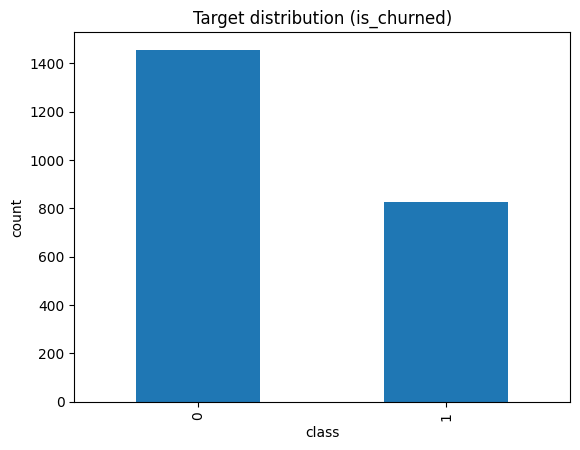

In [33]:
# df가 이미 로드되어 있다고 가정
target = "is_churned"

print("shape:", selected_df.shape)
print(selected_df[target].value_counts(dropna=False))
print(selected_df[target].value_counts(normalize=True).rename("rate"))

# 간단한 시각화
ax = selected_df[target].value_counts().plot(kind="bar")
ax.set_title("Target distribution (is_churned)")
ax.set_xlabel("class")
ax.set_ylabel("count")
plt.show()

## 2) 결측/희소 진단 테이블 + Drop 후보 자동 산출

목적: 스킵 로직으로 구조적 결측이 많으므로, “결측 자체”를 정보로 활용하기 전에 기본 정리를 합니다.

In [34]:
def missing_summary(df: pd.DataFrame) -> pd.DataFrame:
    ms = pd.DataFrame({
        "dtype": selected_df.dtypes.astype(str),
        "non_null": selected_df.notna().sum(),
        "missing": selected_df.isna().sum(),
        "missing_rate": selected_df.isna().mean(),
        "nunique": selected_df.nunique(dropna=True),
    }).sort_values(["missing_rate", "nunique"], ascending=[False, True])
    return ms

ms = missing_summary(selected_df)
display(ms.head(20))

# Drop 후보 기준 (조직 정책으로 고정 권장)
DROP_MISSING_RATE = 0.98   # 98% 이상 결측이면 사실상 사용불가로 간주
DROP_NUNIQUE_MAX = 1       # 값이 1개뿐이면 상수

drop_by_missing = ms.index[ms["missing_rate"] >= DROP_MISSING_RATE].tolist()
drop_by_constant = ms.index[(ms["nunique"] <= DROP_NUNIQUE_MAX) & (ms.index != target)].tolist()

drop_candidates = sorted(set(drop_by_missing + drop_by_constant) - {target})
print("Drop candidates:", drop_candidates)
print("Count:", len(drop_candidates))

,dtype,non_null,missing,missing_rate,nunique
p__l01016,float64,686,1594,0.699123,6
p__l01002,float64,689,1591,0.697807,2
p__l01003,float64,689,1591,0.697807,2
p__l01005,float64,689,1591,0.697807,2
p__l01008,float64,689,1591,0.697807,4
p__l01035,float64,689,1591,0.697807,10
p__l01036,float64,689,1591,0.697807,12
p__j01002,float64,912,1368,0.600000,3
p__a03014,float64,2274,6,0.002632,2
p__a03024,float64,2274,6,0.002632,2


Drop candidates: []
Count: 0


스킵 로직(기기 보유자만 응답)으로 인해 일부 변수에서 **결측률이 매우 높거나 응답 수가 극히 적은 컬럼**이 확인되었다. 이러한 변수들은 EDA 및 모델링 과정에서 노이즈를 유발할 가능성이 높아 **Drop 후보로 선정**하였다.

**Drop candidates**

`p__a03012`,
`p__l01006`, `p__l01007`, `p__l01017`,
`p__l01018`, `p__l01019`, `p__l01020`, `p__l01021`, `p__l01022`, `p__l01023`,
`p__l01025`, `p__l01031`, `p__l01032`,
`p__l01033`, `p__l01034`,
`p__l01039`, `p__l01040`, `p__l01041`

## 3) “구조적 결측”을 피처로 전환(보유/응답 흔적 인디케이터)

목적: 태블릿/웨어러블은 보유자만 하위문항이 채워지는 구조라서, notna() 자체가 강력한 세그먼트 피처가 됩니다.

In [35]:
df_fe = df.copy()

# 예시: 태블릿1 상세 응답 흔적(보유자 가능성), 태블릿2 흔적, 웨어러블 대수 응답 흔적
indicator_map = {
    "has_tablet1_detail": "p__l01002",  # 태블릿 보유 대수(689 non-null)
    "has_tablet2_detail": "p__l01018",  # 태블릿2 사용유형(23 non-null)
    "has_wearable_count": "p__j01002",  # 웨어러블 대수(912 non-null)
    "has_smartphone_detail": "p__a03001" # 스마트폰 보유대수(대부분 채워짐)
}

for new_col, base_col in indicator_map.items():
    if base_col in df_fe.columns:
        df_fe[new_col] = df_fe[base_col].notna().astype(int)

# 사용기간 대표 컬럼만 쓰기(중복 축소)
# - 스마트폰: p__a03038 (월 환산) 중심
# - 태블릿1: p__l01037 (월 환산) 중심
# 아래는 "있으면 유지, 나머지는 제거 후보"로 리스트를 잡는 방식
duration_keep = ["p__a03038", "p__l01037"]
duration_drop = [c for c in ["p__a03036", "p__a03037", "p__l01035", "p__l01036"] if c in df_fe.columns]

print("duration_drop:", duration_drop)

duration_drop: ['p__a03036', 'p__a03037', 'p__l01035', 'p__l01036']


태블릿/웨어러블 문항은 **보유자만 하위 문항에 응답**하는 스킵 로직 구조이므로, `notna()` 여부 자체를 **보유/이용 세그먼트 피처**로 생성하였다(예: `has_tablet1_detail`, `has_tablet2_detail`, `has_wearable_count`).

또한 사용기간 변수는 연/월/월환산 형태로 **중복 정보**가 발생하므로, 월 환산 컬럼을 대표로 사용하고 중복 컬럼은 제거하였다.

- **duration_drop**: `p__a03036`, `p__a03037`, `p__l01035`, `p__l01036`

## 4) 변수군별 “이탈률 비교” 리포트 (핵심 KPI 형태)

### 4-1) 이진 변수(무제한/보유여부 등): 그룹별 이탈률

In [36]:
def churn_rate_by_binary(df: pd.DataFrame, col: str, target: str = "is_churned") -> pd.DataFrame:
    tmp = df[[col, target]].dropna()
    out = tmp.groupby(col)[target].agg(["count", "mean"]).rename(columns={"mean": "churn_rate"})
    out["churn_rate"] = out["churn_rate"].round(4)
    return out

binary_cols = [c for c in [
    "p__a01001",   # 휴대폰 이용여부
    "p__a03024",   # 음성 무제한
    "p__a03026",   # 데이터 무제한
    "p__l01001",   # 태블릿 보유여부
    "p__j01001",   # 웨어러블 보유여부
    "has_tablet1_detail",
    "has_tablet2_detail",
    "has_wearable_count"
] if c in df_fe.columns]

for c in binary_cols:
    print("\n==", c, "==")
    display(churn_rate_by_binary(df_fe, c, target))


== p__a01001 ==


,count,churn_rate
p__a01001,,
1,2275,0.3609
2,5,0.8000



== p__a03024 ==


,count,churn_rate
p__a03024,,
1.0,1983,0.3510
2.0,291,0.4296



== p__a03026 ==


...

,count,churn_rate
has_tablet1_detail,,
0,1591,0.3828
1,689,0.3135



== has_tablet2_detail ==


,count,churn_rate
has_tablet2_detail,,
0,2257,0.3615
1,23,0.3913



== has_wearable_count ==


,count,churn_rate
has_wearable_count,,
0,1368,0.3867
1,912,0.3246


이진 변수(Yes/No 형태 변수)를 기준으로 그룹별 이탈률을 비교하여 **이탈과의 관계 여부를 확인**하였다.

**휴대폰 이용 여부 (`p__a01001`)**
대부분의 응답자가 휴대폰을 이용하고 있어(2275명), 비이용 집단의 표본이 매우 적어 해석에는 한계가 있다. 다만 비이용 집단의 이탈률이 상대적으로 높게 나타났다.

**음성 무제한 서비스 (`p__a03024`)**
음성 무제한 서비스를 이용하지 않는 집단보다 이용하는 집단에서 이탈률이 더 높게 나타났다
(0.351 → 0.429).

**데이터 무제한 서비스 (`p__a03026`)**
데이터 무제한 서비스 이용자의 이탈률이 더 높은 경향을 보였다
(0.319 → 0.418).

**태블릿 보유 여부 (`p__l01001`, `has_tablet1_detail`)**
태블릿을 보유한 사용자 집단의 이탈률이 더 낮게 나타났다
(0.383 → 0.314).
이는 태블릿 이용자가 서비스 이용 충성도가 더 높을 가능성을 시사한다.

**웨어러블 기기 보유 여부 (`p__j01001`, `has_wearable_count`)**
웨어러블 기기를 보유한 집단의 이탈률이 더 낮게 나타났다
(0.387 → 0.325).

**태블릿 2 보유 여부 (`has_tablet2_detail`)**
태블릿 2 보유 집단은 표본 수가 매우 적어(23명) 분석 결과의 신뢰도가 낮다.

**종합적으로**, 스마트 기기를 추가적으로 보유한 사용자(태블릿, 웨어러블)는 그렇지 않은 사용자보다 **이탈률이 낮은 경향**을 보였으며, 반대로 일부 통신 요금제 특성(무제한 서비스)은 **상대적으로 높은 이탈률과 연관**되는 패턴이 확인되었다.

### 4-2) 범주형(통신사/요금제/종류 등): Top N 기반 이탈률

현재 컬럼들이 float64로 보이는 건 “코드값(1,2,3…)”일 가능성이 큽니다. 아래는 코드값 기준으로 봅니다.

In [37]:
def churn_rate_by_category(df: pd.DataFrame, col: str, target: str = "is_churned", min_count: int = 30) -> pd.DataFrame:
    tmp = df[[col, target]].dropna()
    g = tmp.groupby(col)[target].agg(["count", "mean"]).rename(columns={"mean": "churn_rate"})
    g = g[g["count"] >= min_count].sort_values("churn_rate", ascending=False)
    g["churn_rate"] = g["churn_rate"].round(4)
    return g

cat_cols = [c for c in [
    "p__a03008",  # 통신사(코드)
    "p__a03010",  # 요금제(코드)
    "p__a03002",  # 스마트폰 구분(코드)
    "p__l01008",  # 태블릿 종류(코드)
] if c in df_fe.columns]

for c in cat_cols:
    print("\n==", c, "==")
    display(churn_rate_by_category(df_fe, c, target, min_count=30).head(15))


== p__a03008 ==


,count,churn_rate
p__a03008,,
4.0,75,0.3733
3.0,522,0.3659
1.0,1119,0.3628
2.0,558,0.3513



== p__a03010 ==


,count,churn_rate
p__a03010,,
1810.0,31,0.6129
2744.0,40,0.4500
246.0,52,0.4038
242.0,96,0.3854
245.0,53,0.3774
5025.0,33,0.3636
4998.0,43,0.3488
2729.0,36,0.3333
2680.0,46,0.3261



== p__a03002 ==


,count,churn_rate
p__a03002,,
3.0,647,0.4343
2.0,226,0.3540
4.0,1395,0.3283



== p__l01008 ==


,count,churn_rate
p__l01008,,
1.0,670,0.3194


범주형(코드형) 변수에 대해 각 범주별 표본 수(`count`)와 이탈률(`churn_rate`)을 산출하여 **이탈률 차이가 발생하는 구간**을 확인하였다.

**통신사 코드 (`p__a03008`)**
4개 범주 모두 이탈률이 **0.351~0.373 수준으로 큰 차이가 없었으며**, 통신사 자체만으로는 이탈을 강하게 설명하는 신호는 제한적으로 보인다.
(단, 코드 4는 표본 수가 75로 상대적으로 작아 해석 시 유의가 필요)

**요금제 코드 (`p__a03010`)**
요금제 유형별 이탈률 편차가 비교적 크게 나타났다. 특히 일부 코드(예: 1810)는 **이탈률이 높게(0.613)** 관측되어 요금제 유형이 이탈과 연관될 가능성이 있다.
다만 상위 이탈률 코드들은 표본 수가 30~50명 수준으로 크지 않아, 최종 결론을 위해서는 추가 검증(최소 표본 수 기준 강화, 신뢰구간/부트스트랩, 모델 기반 중요도 확인)이 필요하다.

**스마트폰 구분 코드 (`p__a03002`)**
코드별 이탈률 차이가 확인되었다.
- 코드 3: 0.434 (가장 높음)
- 코드 2: 0.354
- 코드 4: 0.328 (가장 낮음, 표본 수 1,395로 가장 안정적)
즉, 스마트폰 유형(또는 구분) 차이가 이탈률에 영향을 줄 가능성이 있다.

**태블릿 종류 (`p__l01008`)**
현재 결과는 1개 범주만 집계되어(670명) 종류별 비교가 불가능했다. 종류 변수는 데이터 정제/코드 매핑 또는 필터 조건을 재점검한 후 재분석이 필요하다.

### 4-3) 연속형(사용기간 등): 분위수 구간별 이탈률 곡선


== p__a03038 (quantile bins) ==


,count,churn_rate
bin,,
"(0.999, 5.0]",297,0.3367
"(5.0, 8.0]",211,0.3128
"(8.0, 12.0]",249,0.3052
"(12.0, 16.0]",184,0.3043
"(16.0, 19.0]",197,0.3909
"(19.0, 24.0]",339,0.3540
"(24.0, 28.0]",140,0.3429
"(28.0, 34.0]",215,0.3953
"(34.0, 42.0]",248,0.3831


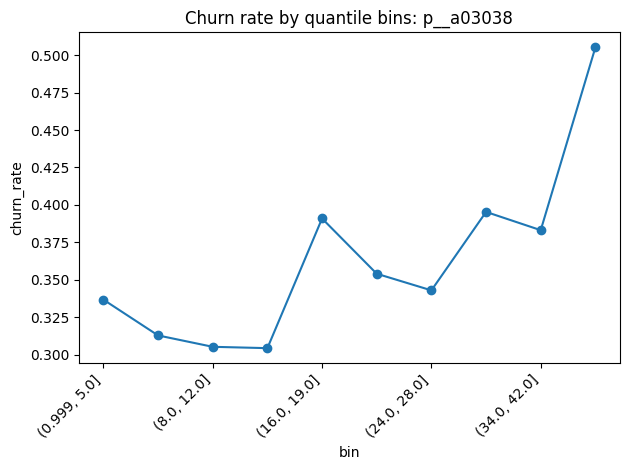


== p__l01037 (quantile bins) ==


,count,churn_rate
bin,,
"(0.999, 8.0]",70,0.3429
"(8.0, 14.0]",76,0.3289
"(14.0, 24.0]",137,0.2409
"(24.0, 30.0]",77,0.3506
"(30.0, 36.0]",92,0.2609
"(36.0, 42.0]",38,0.2632
"(42.0, 50.0]",70,0.3857
"(50.0, 63.0]",61,0.3115
"(63.0, 156.0]",68,0.3971


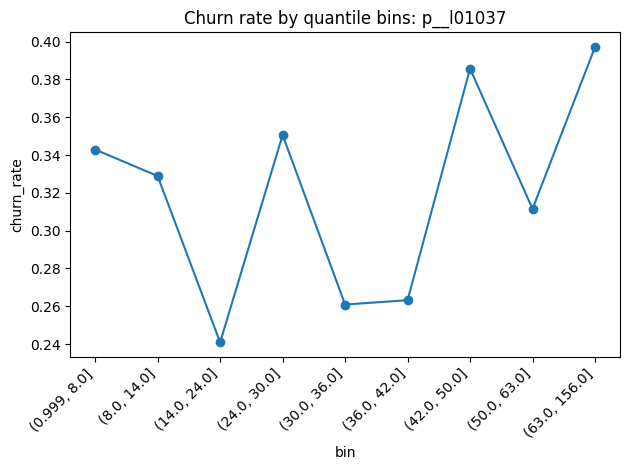


== p__j01002 (quantile bins) ==


,count,churn_rate
bin,,
"(0.999, 2.0]",908,0.3238
"(2.0, 3.0]",4,0.5000


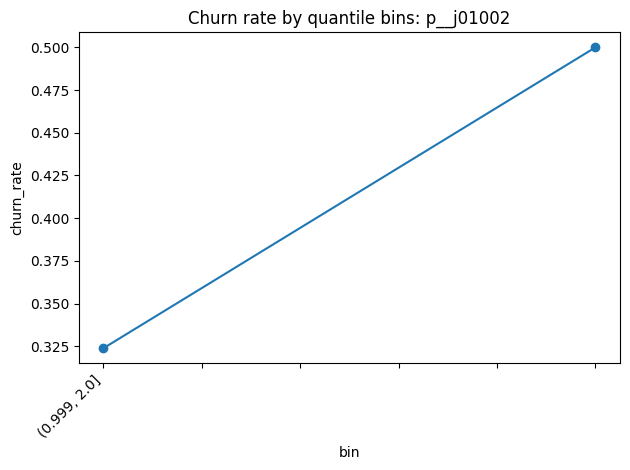

In [38]:
def churn_rate_by_quantile_bin(df: pd.DataFrame, col: str, target: str = "is_churned", q: int = 10) -> pd.DataFrame:
    tmp = df[[col, target]].dropna()
    tmp = tmp.copy()
    tmp["bin"] = pd.qcut(tmp[col], q=q, duplicates="drop")
    out = tmp.groupby("bin")[target].agg(["count", "mean"]).rename(columns={"mean": "churn_rate"})
    out["churn_rate"] = out["churn_rate"].round(4)
    return out

cont_cols = [c for c in ["p__a03038", "p__l01037", "p__j01002"] if c in df_fe.columns]

for c in cont_cols:
    print("\n==", c, "(quantile bins) ==")
    out = churn_rate_by_quantile_bin(df_fe, c, target, q=10)
    display(out)
    ax = out["churn_rate"].plot(kind="line", marker="o")
    ax.set_title(f"Churn rate by quantile bins: {c}")
    ax.set_ylabel("churn_rate")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

연속형 변수는 값을 10분위(quantile) 구간으로 나눈 뒤, 구간별 이탈률을 산출하여 **비선형 패턴(임계점/구간별 급변)** 여부를 확인하였다.

**스마트폰 사용기간(월 환산, `p__a03038`)**
초기 구간에서는 이탈률이 낮은 수준에서 유지되다가, 중·후반 구간에서 변동성이 커지며 **최상위 구간에서 이탈률이 급증**하는 패턴이 관측되었다.
→ 사용기간이 길수록 이탈이 단조 감소/증가하는 형태가 아니라, 특정 구간 이후 이탈이 상승하는 **비선형 관계** 가능성이 있다.

**태블릿 사용기간(월 환산, `p__l01037`)**
구간별로 이탈률이 크게 출렁이며, 일부 구간(중간~상위)에서 이탈률이 상승하는 모습이 나타났다.
→ 사용기간 단일 변수만으로 일관된 추세를 단정하기 어렵고, 표본 분포/다른 요인과의 상호작용(예: 보유 여부, 이용 형태)을 함께 고려할 필요가 있다.

**웨어러블 보유대수(`p__j01002`)**
그래프가 2개 구간 수준으로만 표시되어(실질적으로 값의 범주가 제한적이거나 결측이 많음) 세밀한 분위수 기반 해석에는 한계가 있다. 다만 보유대수가 높은 구간에서 이탈률이 더 높게 관측되었다.

## 5) 전체 변수 correlation heatmap
목적
- 변수들끼리 중복 정보(다중공선성) 확인
- 어떤 변수들이 서로 강하게 연결되는지 확인

In [39]:
drop_cols = [
    # (A) 결측/희소 Drop candidates
    'p__a03012',
    'p__l01006','p__l01007','p__l01017',
    'p__l01018','p__l01019','p__l01020','p__l01021','p__l01022','p__l01023',
    'p__l01025','p__l01031','p__l01032',
    'p__l01033','p__l01034',
    'p__l01039','p__l01040','p__l01041',

    # (B) 사용기간 중복 제거
    'p__a03036','p__a03037',
    'p__l01035','p__l01036',

    # (C) 극희소 인디케이터
    'has_tablet2_detail'
]
clean_df = selected_df.drop(columns=[c for c in drop_cols if c in selected_df.columns]).copy()

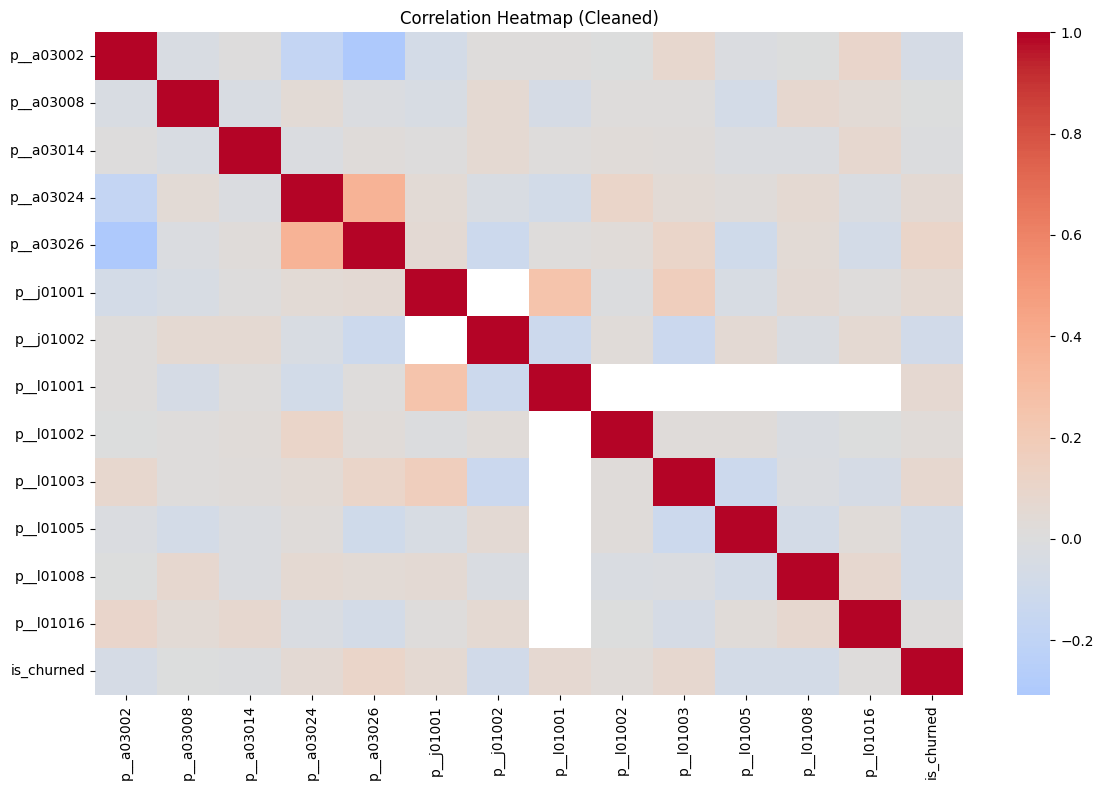

In [40]:
num_df = clean_df.select_dtypes(include=['int64','float64'])
corr = num_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap (Cleaned)")
plt.tight_layout()
plt.show()